# Credit Card Fraud Detection — Data Quality Inspection

This notebook checks:
- Column structure
- Missing values
- Data types
- Target class
- Invalid and noisy values
- Duplicate rows
- Outliers

No rows or values are modified or removed.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 1. Load Data

In [2]:
DATA_PATH = Path("../data/raw/creditcard.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Column Structure

In [3]:
expected_features = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]
target_column = "Class"
expected_columns = expected_features + [target_column]

actual_columns = list(df.columns)
missing_columns = sorted(set(expected_columns) - set(actual_columns))
unexpected_columns = sorted(set(actual_columns) - set(expected_columns))

schema_report = pd.DataFrame({
    "check": [
        "Expected column count",
        "Actual column count",
        "Missing columns",
        "Unexpected columns",
        "Correct column order"
    ],
    "result": [
        len(expected_columns),
        len(actual_columns),
        missing_columns,
        unexpected_columns,
        actual_columns == expected_columns
    ]
})

schema_report


,check,result
0,Expected column count,31
1,Actual column count,31
2,Missing columns,[]
3,Unexpected columns,[]
4,Correct column order,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 3. Missing Values

In [6]:
missing_report = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (
        df.isna().sum().values / len(df) * 100
    )
})

missing_report["missing_percentage"] = (
    missing_report["missing_percentage"].round(6)
)

missing_report.sort_values(
    by="missing_count",
    ascending=False
).reset_index(drop=True)


,column,missing_count,missing_percentage
0,Time,0,0.0
1,V1,0,0.0
2,V2,0,0.0
3,V3,0,0.0
4,V4,0,0.0
5,V5,0,0.0
6,V6,0,0.0
7,V7,0,0.0
8,V8,0,0.0
9,V9,0,0.0


## 4. Data Types

In [7]:
data_type_report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "is_numeric": [
        pd.api.types.is_numeric_dtype(df[column])
        for column in df.columns
    ],
    "unique_values": [
        df[column].nunique(dropna=True)
        for column in df.columns
    ]
})

data_type_report


,column,dtype,is_numeric,unique_values
0,Time,float64,True,124592
1,V1,float64,True,275663
2,V2,float64,True,275663
3,V3,float64,True,275663
4,V4,float64,True,275663
5,V5,float64,True,275663
6,V6,float64,True,275663
7,V7,float64,True,275663
8,V8,float64,True,275663
9,V9,float64,True,275663


In [8]:
non_numeric_report = []

for column in df.columns:
    converted = pd.to_numeric(df[column], errors="coerce")

    non_numeric_report.append({
        "column": column,
        "invalid_numeric_count": int(
            (converted.isna() & df[column].notna()).sum()
        )
    })

non_numeric_report = pd.DataFrame(non_numeric_report)
non_numeric_report


,column,invalid_numeric_count
0,Time,0
1,V1,0
2,V2,0
3,V3,0
4,V4,0
5,V5,0
6,V6,0
7,V7,0
8,V8,0
9,V9,0


## 5. Target Class

In [9]:
if target_column not in df.columns:
    raise KeyError(f"Target column not found: {target_column}")

class_distribution = (
    df[target_column]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Class")
    .reset_index(name="count")
)

class_distribution["percentage"] = (
    class_distribution["count"] / len(df) * 100
).round(6)

class_distribution


,Class,count,percentage
0,0,284315,99.827251
1,1,492,0.172749


In [10]:
invalid_class_mask = (
    df[target_column].notna()
    & ~df[target_column].isin([0, 1])
)

target_report = pd.DataFrame({
    "check": [
        "Missing Class values",
        "Invalid Class values",
        "Fraud transactions",
        "Legitimate transactions"
    ],
    "result": [
        int(df[target_column].isna().sum()),
        int(invalid_class_mask.sum()),
        int((df[target_column] == 1).sum()),
        int((df[target_column] == 0).sum())
    ]
})

target_report


,check,result
0,Missing Class values,0
1,Invalid Class values,0
2,Fraud transactions,492
3,Legitimate transactions,284315


## 6. Invalid and Noisy Values

In [11]:
numeric_df = df.select_dtypes(include=np.number)

infinity_report = pd.DataFrame({
    "column": numeric_df.columns,
    "positive_infinity_count": [
        int(np.isposinf(numeric_df[column]).sum())
        for column in numeric_df.columns
    ],
    "negative_infinity_count": [
        int(np.isneginf(numeric_df[column]).sum())
        for column in numeric_df.columns
    ]
})

infinity_report["total_infinity_count"] = (
    infinity_report["positive_infinity_count"]
    + infinity_report["negative_infinity_count"]
)

infinity_report


,column,positive_infinity_count,negative_infinity_count,total_infinity_count
0,Time,0,0,0
1,V1,0,0,0
2,V2,0,0,0
3,V3,0,0,0
4,V4,0,0,0
5,V5,0,0,0
6,V6,0,0,0
7,V7,0,0,0
8,V8,0,0,0
9,V9,0,0,0


In [12]:
noise_report = pd.DataFrame({
    "check": [
        "Negative Time values",
        "Negative Amount values",
        "Missing Class values",
        "Invalid Class values",
        "Infinite values",
        "Non-numeric values"
    ],
    "count": [
        int((df["Time"] < 0).sum()),
        int((df["Amount"] < 0).sum()),
        int(df[target_column].isna().sum()),
        int(invalid_class_mask.sum()),
        int(infinity_report["total_infinity_count"].sum()),
        int(non_numeric_report["invalid_numeric_count"].sum())
    ]
})

noise_report


,check,count
0,Negative Time values,0
1,Negative Amount values,0
2,Missing Class values,0
3,Invalid Class values,0
4,Infinite values,0
5,Non-numeric values,0


## 7. Duplicate Rows

In [13]:
duplicate_mask = df.duplicated(keep=False)

duplicate_report = pd.DataFrame({
    "check": [
        "Rows in duplicate groups",
        "Extra duplicate rows",
        "Duplicate percentage"
    ],
    "result": [
        int(duplicate_mask.sum()),
        int(df.duplicated().sum()),
        round(df.duplicated().mean() * 100, 6)
    ]
})

duplicate_report


,check,result
0,Rows in duplicate groups,1854.000000
1,Extra duplicate rows,1081.000000
2,Duplicate percentage,0.379555


In [14]:
duplicate_rows = df.loc[duplicate_mask]
duplicate_rows.head(20)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.872490,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.872490,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.871800,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.871800,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,0.158497,-1.224951,1.314705,0.304412,-0.290218,-2.014548,-0.772801,0.696761,0.017914,2.177250,-0.276207,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,0.158497,-1.224951,1.314705,0.304412,-0.290218,-2.014548,-0.772801,0.696761,0.017914,2.177250,-0.276207,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


## 8. Outlier Detection

In [15]:
outlier_results = []

for column in numeric_df.columns:
    if column == target_column:
        continue

    series = df[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (df[column] < lower_bound)
        | (df[column] > upper_bound)
    )

    outlier_results.append({
        "column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_percentage": round(
            outlier_mask.mean() * 100,
            6
        )
    })

outlier_report = pd.DataFrame(outlier_results)

outlier_report = outlier_report.sort_values(
    by="outlier_count",
    ascending=False
).reset_index(drop=True)

outlier_report


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,V27,-0.070840,0.091045,0.161885,-0.313667,0.333872,39163,13.750715
1,Amount,5.600000,77.165000,71.565000,-101.747500,184.512500,31904,11.201972
2,V28,-0.052960,0.078280,0.131240,-0.249819,0.275140,30342,10.653530
3,V20,-0.211721,0.133041,0.344762,-0.728865,0.650184,27770,9.750463
4,V8,-0.208630,0.327346,0.535976,-1.012593,1.131309,24134,8.473809
5,V6,-0.768296,0.398565,1.166861,-2.518586,2.148856,22965,8.063355
6,V23,-0.161846,0.147642,0.309488,-0.626079,0.611875,18541,6.510023
7,V12,-0.405571,0.618238,1.023810,-1.941286,2.153952,15348,5.388912
8,V21,-0.228395,0.186377,0.414772,-0.850553,0.808535,14497,5.090114
9,V14,-0.425574,0.493150,0.918724,-1.803660,1.871236,14149,4.967926


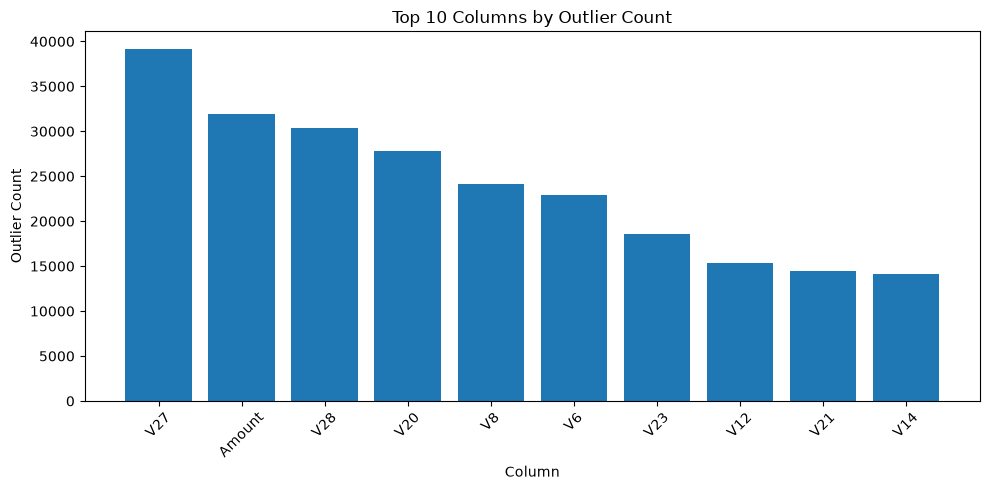

In [16]:
top_outlier_columns = outlier_report.head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    top_outlier_columns["column"],
    top_outlier_columns["outlier_count"]
)
plt.title("Top 10 Columns by Outlier Count")
plt.xlabel("Column")
plt.ylabel("Outlier Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Summary

In [17]:
summary = pd.DataFrame({
    "check": [
        "Rows",
        "Columns",
        "Missing values",
        "Invalid Class values",
        "Negative Time values",
        "Negative Amount values",
        "Infinite values",
        "Non-numeric values",
        "Extra duplicate rows",
        "Columns with outliers"
    ],
    "result": [
        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(invalid_class_mask.sum()),
        int((df["Time"] < 0).sum()),
        int((df["Amount"] < 0).sum()),
        int(infinity_report["total_infinity_count"].sum()),
        int(non_numeric_report["invalid_numeric_count"].sum()),
        int(df.duplicated().sum()),
        int((outlier_report["outlier_count"] > 0).sum())
    ]
})

summary


,check,result
0,Rows,284807
1,Columns,31
2,Missing values,0
3,Invalid Class values,0
4,Negative Time values,0
5,Negative Amount values,0
6,Infinite values,0
7,Non-numeric values,0
8,Extra duplicate rows,1081
9,Columns with outliers,29


## 10. Final Validation

In [18]:
assert df.shape[1] == 31
assert set(df[target_column].dropna().unique()).issubset({0, 1})
assert not np.isinf(numeric_df.to_numpy()).any()

print("Data quality inspection completed successfully.")


Data quality inspection completed successfully.
